In [6]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
from datetime import datetime

os.environ['TZ'] = 'Europe/Berlin'
import time
time.tzset()

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

In [4]:

OUT_DIR = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_violins_per_MP_celltype"
os.makedirs(OUT_DIR, exist_ok=True)

adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_extended_gbmap_hgnc.h5ad")
mp_scores = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/04_NMF_GSEAonHGNC/04_3_nmf_all_gsea_c7/mp_scores.csv", index_col=0)


In [5]:
for col in mp_scores.columns:
    if col not in adata.obs.columns:
        adata.obs[col] = mp_scores[col].reindex(adata.obs_names).values

mp_score_cols = mp_scores.columns.tolist()
checkpoint(f"Found {len(mp_score_cols)} MP score columns")



[2026-09-27 16:10:40] Found 30 MP score columns


### violin plot all MPs per celltype

In [ ]:
n_mps = len(mp_score_cols)
n_cols = 5
n_rows = -(-n_mps // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, mp_col in enumerate(mp_score_cols):
    mp_name = mp_col.replace("_score", "")
    sc.pl.violin(adata, keys=mp_col, groupby="annotation_level_3", rotation=45, show=False, ax=axes[i], stripplot=False)
    axes[i].set_title(mp_name, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(f"{mp_name} score", fontsize=8)

for j in range(n_mps, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "violin_all_MPs_per_celltype_compressed.pdf"), dpi=120, bbox_inches="tight")
plt.close()
checkpoint("Combined PDF with all MP violin plots saved")

### cell count per SELECTED MPS

In [16]:
SELECTED_MPS = ["MP1", "MP2", "MP7", "MP8", "MP9", "MP11", "MP14", "MP15", "MP19", "MP20"]
score_columns = [f"{mp}_score" for mp in SELECTED_MPS]

missing_columns = sorted(set(score_columns) - set(mp_scores.columns))

if missing_columns:
    raise ValueError(
        f"Score columns missing from mp_scores: {missing_columns}"
    )


In [17]:
mp_scores_selected = mp_scores.loc[adata.obs_names, score_columns].copy()


In [18]:
# Assign the original MP name, not the *_score column name
adata.obs["dominant_selected_mp"] = (
    mp_scores_selected
    .idxmax(axis=1)
    .str.replace("_score", "", regex=False)
)

# Store the winning score
adata.obs["dominant_selected_mp_score"] = mp_scores_selected.max(axis=1)

In [22]:
common_cells = mp_scores.index.intersection(adata.obs_names)
n_dropped_mp = len(mp_scores) - len(common_cells)
n_dropped_adata = adata.n_obs - len(common_cells)
checkpoint(
    f"Common cells: {len(common_cells)} "
    f"(dropping {n_dropped_mp} mp_scores-only cells, {n_dropped_adata} adata-only cells)"
)
mp_scores = mp_scores.loc[common_cells]


checkpoint("Computing dominant MP per cell")
order_map = {mp: i for i, mp in enumerate(SELECTED_MPS)}


[2026-09-27 17:08:50] Common cells: 633710 (dropping 0 mp_scores-only cells, 0 adata-only cells)
[2026-09-27 17:08:50] Computing dominant MP per cell


In [24]:
# Selected MP score columns
score_columns = [f"{mp}_score" for mp in SELECTED_MPS]
mp_scores_selected = mp_scores.loc[adata.obs_names, score_columns].copy()

# Convert score-column names back to MP names
mp_scores_selected.columns = (
    mp_scores_selected.columns
    .str.replace("_score", "", regex=False)
)

# Dominant MP based on the highest score among selected MPs
dominant_mp = mp_scores_selected.idxmax(axis=1)

# Score of each cell's dominant MP
own_score_all = mp_scores_selected.max(axis=1).to_numpy()

# Per-MP 75th-percentile thresholds
per_mp_threshold = mp_scores_selected.quantile(0.75, axis=0)

# Threshold corresponding to each cell's dominant MP
own_threshold = dominant_mp.map(per_mp_threshold).to_numpy()

# Keep only cells whose dominant score exceeds its MP-specific threshold
dominant_MP_selected = pd.Series(
    np.where(
        own_score_all > own_threshold,
        dominant_mp.to_numpy(),
        "Other"
    ),
    index=mp_scores_selected.index,
    name="dominant_selected_mp"
)

# Keep only the ten selected MPs
keep_mask = dominant_MP_selected.isin(SELECTED_MPS)

checkpoint(
    f"Keeping {keep_mask.sum()} / {len(keep_mask)} cells "
    f"({100 * keep_mask.mean():.2f} %) with score > MP-specific 75th percentile"
)

# Counts per MP, including MPs with zero retained cells
cell_counts_75 = (
    dominant_MP_selected[keep_mask]
    .value_counts()
    .reindex(SELECTED_MPS, fill_value=0)
    .rename_axis("MP")
    .rename("n_cells")
    .reset_index()
)

print(cell_counts_75)
print(f"Total retained cells: {cell_counts_75['n_cells'].sum()}")
print(f"Other / excluded cells: {(~keep_mask).sum()}")

[2026-09-27 17:15:09] Keeping 235261 / 633710 cells (37.12 %) with score > MP-specific 75th percentile
     MP  n_cells
0   MP1    14773
1   MP2     4578
2   MP7    12206
3   MP8     3138
4   MP9     8517
5  MP11      755
6  MP14    25864
7  MP15   158277
8  MP19     2070
9  MP20     5083
Total retained cells: 235261
Other / excluded cells: 398449


### barplot all cells


In [19]:
cell_counts = (
    adata.obs["dominant_selected_mp"]
    .value_counts()
    .reindex(SELECTED_MPS, fill_value=0)
    .rename_axis("MP")
    .rename("n_cells")
    .reset_index()
)

print(cell_counts)

     MP  n_cells
0   MP1    14787
1   MP2     4578
2   MP7    14588
3   MP8     3200
4   MP9     8663
5  MP11      758
6  MP14    77031
7  MP15   502265
8  MP19     2186
9  MP20     5654


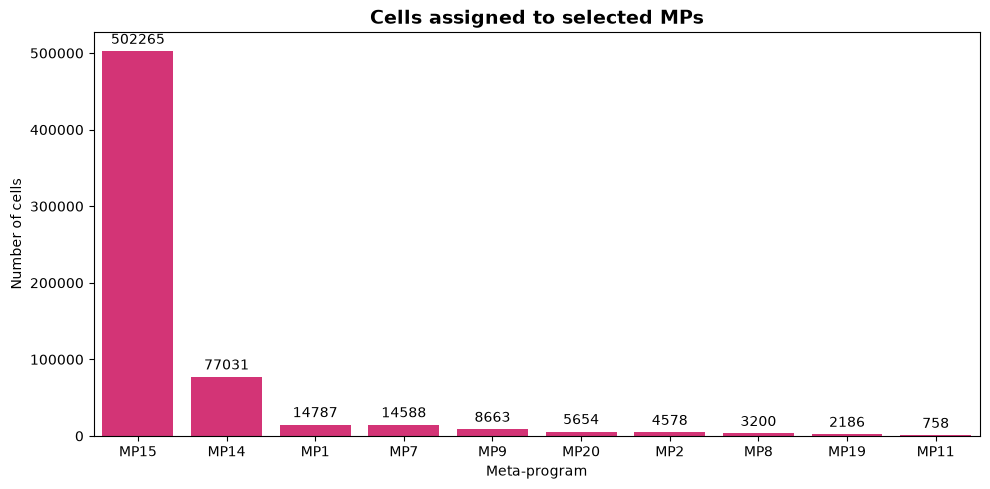

In [26]:
plot_df = cell_counts[cell_counts["MP"].notna()].sort_values("n_cells", ascending=False)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=plot_df,
    x="MP",
    y="n_cells",
    color="#ed1a72"
)

ax.set_title("Cells assigned to selected MPs", fontsize=14, fontweight="bold")
ax.set_xlabel("Meta-program")
ax.set_ylabel("Number of cells")
ax.tick_params(axis="x")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "05_07_cell_counts_selMPs.pdf"),
    bbox_inches="tight"
)
plt.show()
plt.close()

### barplot 75th percentile cells

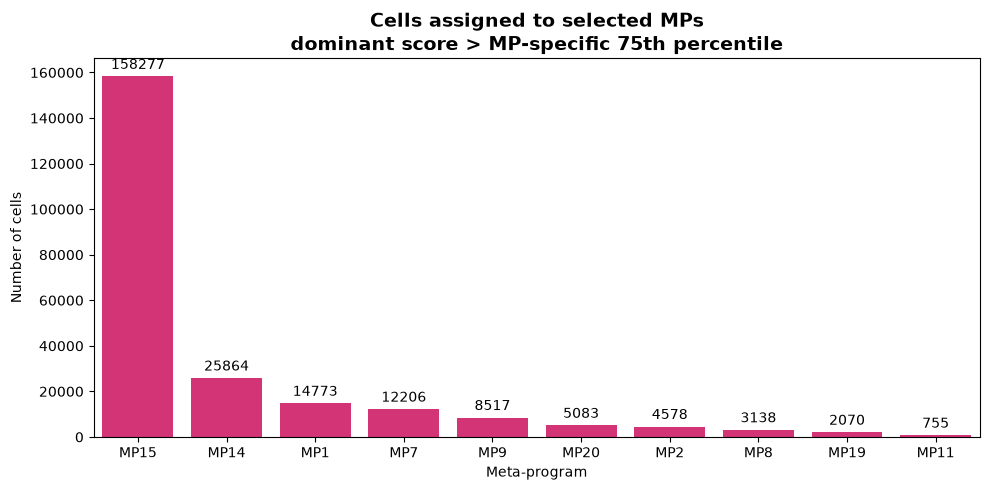

In [29]:
plot_df = cell_counts_75[cell_counts_75["MP"].notna()].sort_values("n_cells", ascending=False)
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=plot_df,
    x="MP",
    y="n_cells",
    color="#ed1a72"
)

ax.set_title("Cells assigned to selected MPs\n"
    "dominant score > MP-specific 75th percentile", fontsize=14, fontweight="bold")
ax.set_xlabel("Meta-program")
ax.set_ylabel("Number of cells")
ax.tick_params(axis="x")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "05_07_cell_counts_selMPs_75th.pdf"),
    bbox_inches="tight"
)
plt.show()
plt.close()